# Addon Task: Regression Basics
**Mentee Contribution | SURE Trust G40 AI/ML Batch**
**Topic: Regression Analysis and Answers to Key Interview Questions**

---

## Project Overview
This notebook presents a comprehensive hands-on implementation of regression models using the **Medical Insurance Cost dataset (`dataset.csv`)**. 

We perform:
1. **Exploratory Data Analysis (EDA)** using **Polars** and **Seaborn**.
2. **Data Preprocessing** (encoding categorical variables, train-test splitting, feature standardization).
3. **Model Implementation**:
   - Simple Linear Regression
   - Multiple Linear Regression
   - Ridge Regression (L2)
   - Lasso Regression (L1 with Feature Selection)
   - Elastic Net Regression (L1 + L2)
4. **Model Performance Evaluation & Comparison** using MAE, MSE, RMSE, $R^2$, and Adjusted $R^2$.
5. **Answers to the 20 Core Regression Interview Questions**.


### 1. Setup and Library Imports

In [1]:
import os
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


### 2. Loading Dataset with Polars
Polars is a high-performance DataFrame library built in Rust, optimized for speed and memory efficiency. We will use Polars to load and perform initial inspections on the insurance dataset.

In [2]:
# Load dataset
df_pl = pl.read_csv("dataset.csv")

print("Dataset Shape:", df_pl.shape)
print("Columns and Data Types:")
print(df_pl.schema)

# Display first 5 rows
print("\nFirst 5 rows of the dataset:")
print(df_pl.head(5))


Dataset Shape: (1338, 7)
Columns and Data Types:
Schema({'age': Int64, 'sex': String, 'bmi': Float64, 'children': Int64, 'smoker': String, 'region': String, 'charges': Float64})

First 5 rows of the dataset:
shape: (5, 7)
┌─────┬────────┬────────┬──────────┬────────┬───────────┬─────────────┐
│ age ┆ sex    ┆ bmi    ┆ children ┆ smoker ┆ region    ┆ charges     │
│ --- ┆ ---    ┆ ---    ┆ ---      ┆ ---    ┆ ---       ┆ ---         │
│ i64 ┆ str    ┆ f64    ┆ i64      ┆ str    ┆ str       ┆ f64         │
╞═════╪════════╪════════╪══════════╪════════╪═══════════╪═════════════╡
│ 19  ┆ female ┆ 27.9   ┆ 0        ┆ yes    ┆ southwest ┆ 16884.924   │
│ 18  ┆ male   ┆ 33.77  ┆ 1        ┆ no     ┆ southeast ┆ 1725.5523   │
│ 28  ┆ male   ┆ 33.0   ┆ 3        ┆ no     ┆ southeast ┆ 4449.462    │
│ 33  ┆ male   ┆ 22.705 ┆ 0        ┆ no     ┆ northwest ┆ 21984.47061 │
│ 32  ┆ male   ┆ 28.88  ┆ 0        ┆ no     ┆ northwest ┆ 3866.8552   │
└─────┴────────┴────────┴──────────┴────────┴───────────┴─

Let's get basic summary statistics and check for missing values using Polars.

In [3]:
# Summary statistics
print("Summary Statistics:")
print(df_pl.describe())

# Check for nulls
print("\nNull value count per column:")
for col in df_pl.columns:
    null_count = df_pl[col].null_count()
    print(f"{col}: {null_count}")


Summary Statistics:
shape: (9, 8)
┌────────────┬───────────┬────────┬───────────┬──────────┬────────┬───────────┬──────────────┐
│ statistic  ┆ age       ┆ sex    ┆ bmi       ┆ children ┆ smoker ┆ region    ┆ charges      │
│ ---        ┆ ---       ┆ ---    ┆ ---       ┆ ---      ┆ ---    ┆ ---       ┆ ---          │
│ str        ┆ f64       ┆ str    ┆ f64       ┆ f64      ┆ str    ┆ str       ┆ f64          │
╞════════════╪═══════════╪════════╪═══════════╪══════════╪════════╪═══════════╪══════════════╡
│ count      ┆ 1338.0    ┆ 1338   ┆ 1338.0    ┆ 1338.0   ┆ 1338   ┆ 1338      ┆ 1338.0       │
│ null_count ┆ 0.0       ┆ 0      ┆ 0.0       ┆ 0.0      ┆ 0      ┆ 0         ┆ 0.0          │
│ mean       ┆ 39.207025 ┆ null   ┆ 30.663397 ┆ 1.094918 ┆ null   ┆ null      ┆ 13270.422265 │
│ std        ┆ 14.04996  ┆ null   ┆ 6.098187  ┆ 1.205493 ┆ null   ┆ null      ┆ 12110.011237 │
│ min        ┆ 18.0      ┆ female ┆ 15.96     ┆ 0.0      ┆ no     ┆ northeast ┆ 1121.8739    │
│ 25%        ┆ 2

### 3. Exploratory Data Analysis & Visualizations
Let's convert our Polars DataFrame to Pandas for easy plotting and visualization.

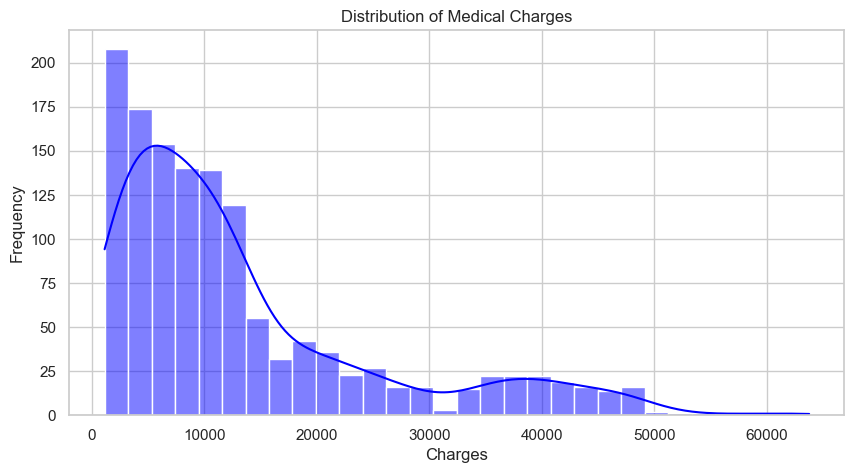

In [4]:
# Convert to pandas
df = df_pl.to_pandas()

# Plot distribution of the target variable 'charges'
plt.figure(figsize=(10, 5))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()


Let's analyze how the categorical variables (`smoker`, `sex`, `region`) affect the charges using box plots.

C:\Users\Harshitha\AppData\Local\Temp\ipykernel_21336\259562430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=df, x='smoker', y='charges', palette='Set1')
C:\Users\Harshitha\AppData\Local\Temp\ipykernel_21336\259562430.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='sex', y='charges', palette='Set2')
C:\Users\Harshitha\AppData\Local\Temp\ipykernel_21336\259562430.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], data=df, x='region', y='charges', palette='Set3')


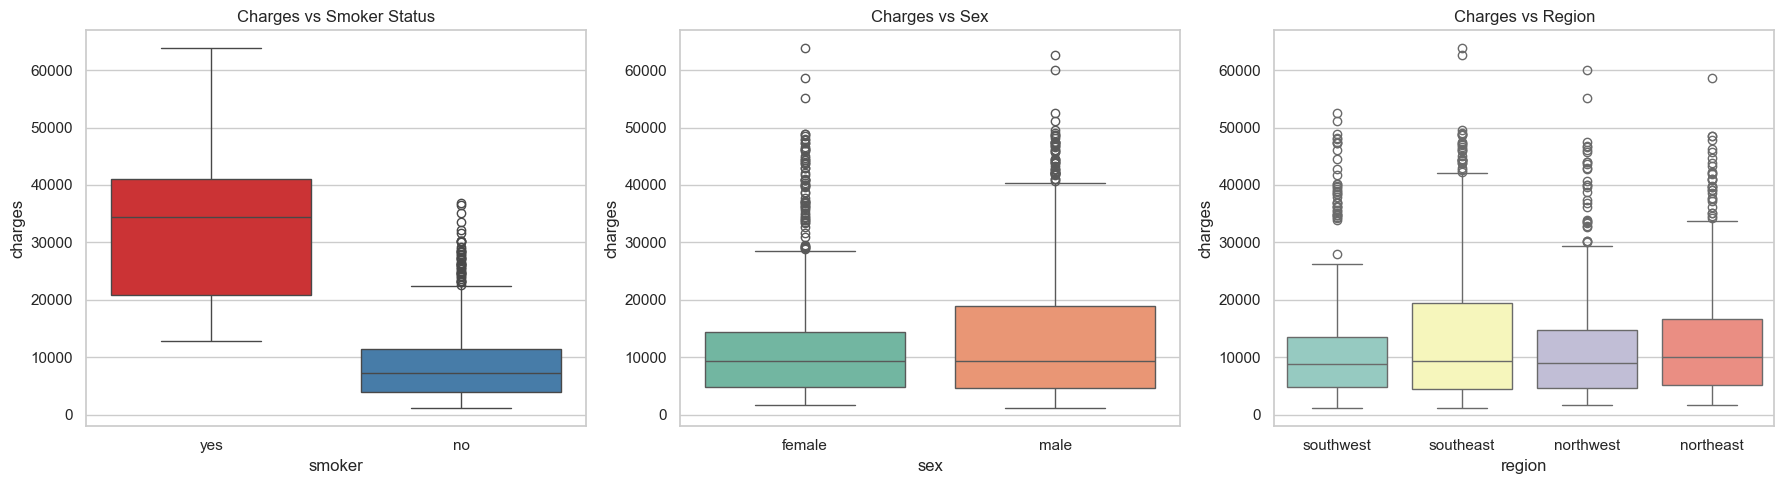

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], data=df, x='smoker', y='charges', palette='Set1')
axes[0].set_title("Charges vs Smoker Status")

sns.boxplot(ax=axes[1], data=df, x='sex', y='charges', palette='Set2')
axes[1].set_title("Charges vs Sex")

sns.boxplot(ax=axes[2], data=df, x='region', y='charges', palette='Set3')
axes[2].set_title("Charges vs Region")

plt.tight_layout()
plt.show()


Let's plot BMI vs Charges, colored by Smoker Status, to see the interaction between these two variables.

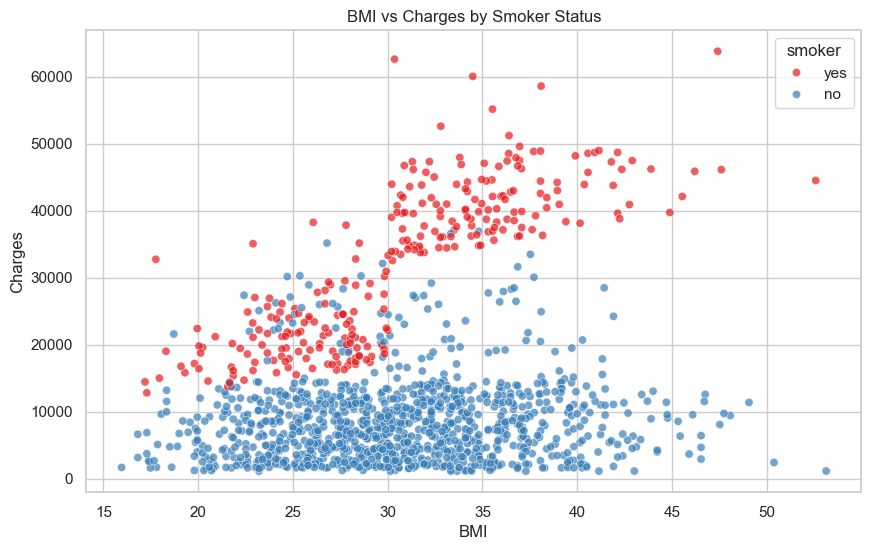

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", palette="Set1", alpha=0.7)
plt.title("BMI vs Charges by Smoker Status")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()


### 4. Data Preprocessing & Categorical Encoding
We will use one-hot encoding for categorical variables (`sex`, `smoker`, `region`) and split the data into 80% train and 20% test sets.

In [7]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)

# Cast boolean columns to integers
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
         df_encoded[col] = df_encoded[col].astype(int)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=["charges"])
y = df_encoded["charges"]

print("Encoded features list:")
print(X.columns.tolist())


Encoded features list:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


Let's check correlation heatmap after encoding.

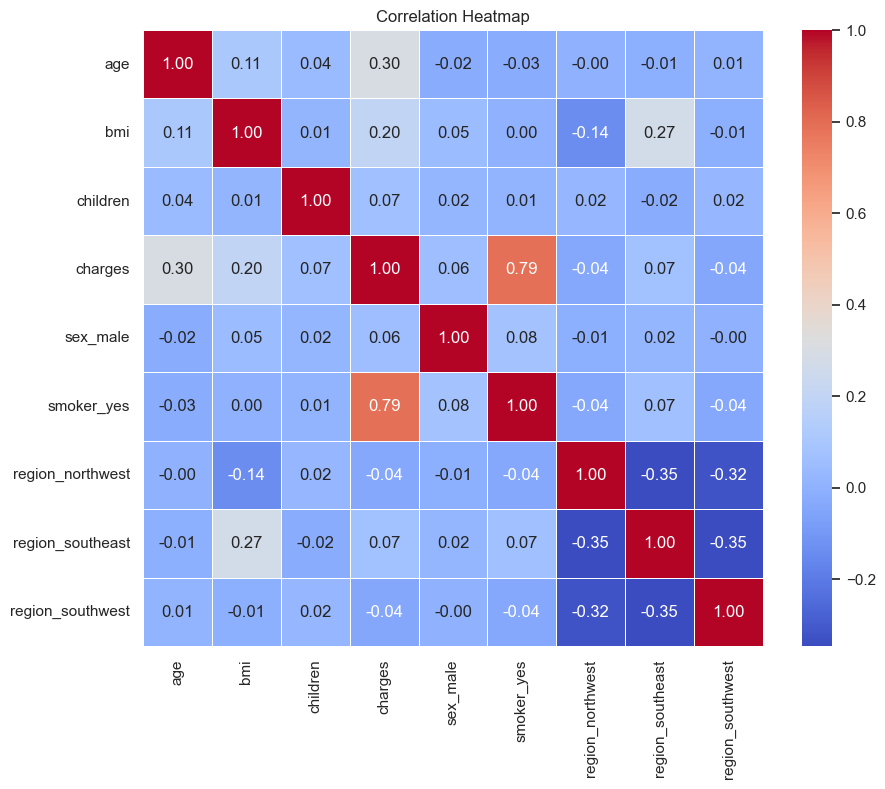

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


Now, split into train and test sets and scale the numerical features (`age`, `bmi`, `children`) using `StandardScaler`.

In [9]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numeric columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = ["age", "bmi", "children"]
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)


X_train shape: (1070, 8)
X_test shape: (268, 8)


### 5. Regression Modeling & Evaluation
Let's first build a **Simple Linear Regression** model using `bmi` as the only predictor.

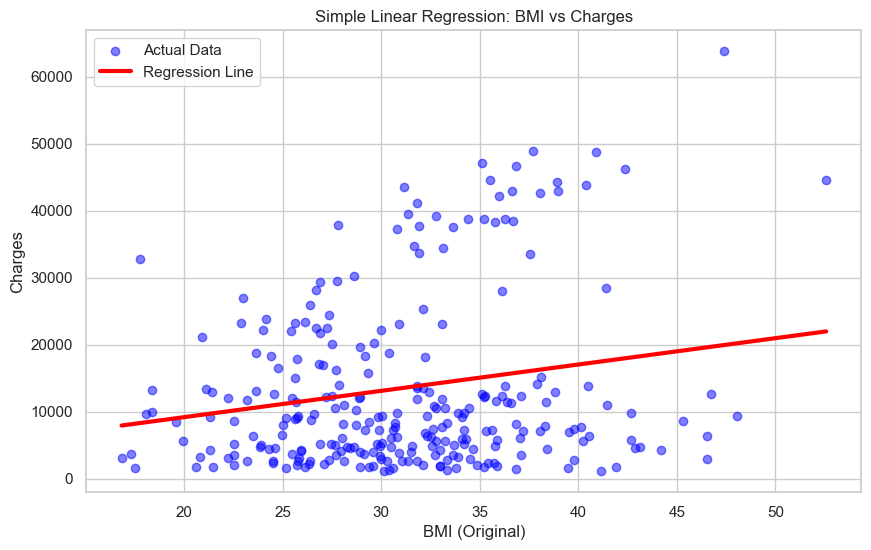

In [10]:
# Simple Linear Regression (predict charges using bmi)
X_train_simple = X_train_scaled[["bmi"]]
X_test_simple = X_test_scaled[["bmi"]]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)
y_pred_simple = simple_model.predict(X_test_simple)

# Plot simple linear regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_test["bmi"], y_test, color="blue", alpha=0.5, label="Actual Data")
sort_idx = np.argsort(X_test["bmi"])
plt.plot(X_test["bmi"].iloc[sort_idx], y_pred_simple[sort_idx], color="red", linewidth=3, label="Regression Line")
plt.title("Simple Linear Regression: BMI vs Charges")
plt.xlabel("BMI (Original)")
plt.ylabel("Charges")
plt.legend()
plt.show()


Now let's run all the multivariate models: Multiple Linear Regression, Ridge, Lasso, and Elastic Net.

In [11]:
# Define multiple models
models = {
    "Multiple Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=1.0),
    "Elastic Net Regression": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Calculate Adjusted R-squared
    n = len(y_test)
    p = X_train_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted R2": adj_r2,
        "predictions": y_pred,
        "model": model
    }


### 6. Model Comparison & Analysis

In [12]:
# Compile comparison table
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        "Model": name,
        "MAE": metrics["MAE"],
        "MSE": metrics["MSE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "Adjusted R2": metrics["Adjusted R2"]
    })

df_comparison = pd.DataFrame(comparison_data)
print("Model Comparison Summary:")
print(df_comparison.to_string(index=False))


Model Comparison Summary:
                     Model         MAE          MSE        RMSE       R2  Adjusted R2
Multiple Linear Regression 4181.194474 3.359692e+07 5796.284659 0.783593     0.776909
          Ridge Regression 4193.195353 3.364539e+07 5800.464938 0.783281     0.776587
          Lasso Regression 4182.219786 3.360573e+07 5797.044759 0.783536     0.776850
    Elastic Net Regression 7538.308285 9.411359e+07 9701.216032 0.393788     0.375064


Let's visualize actual vs predicted charges for Multiple Linear Regression, along with a Residual Plot to check model assumptions.

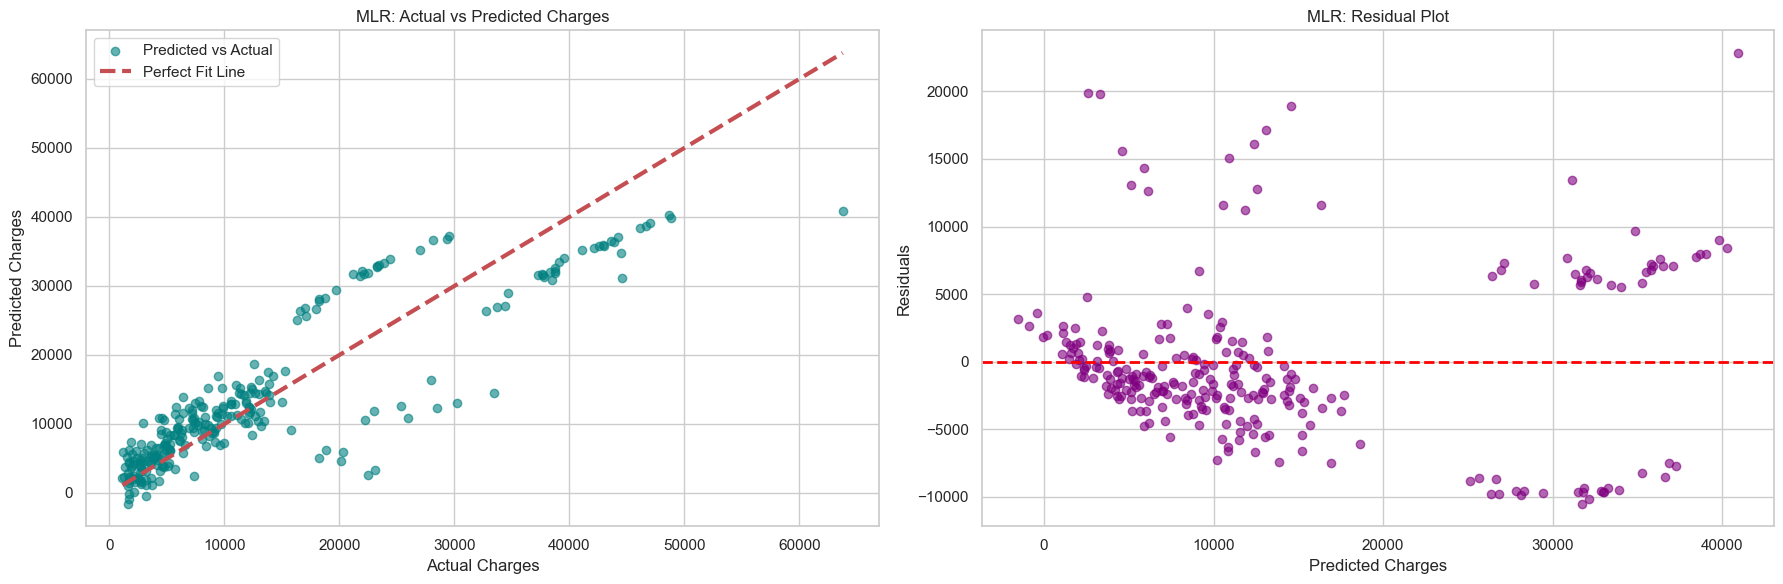

In [13]:
y_pred_mlr = results["Multiple Linear Regression"]["predictions"]
residuals = y_test - y_pred_mlr

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_mlr, color="teal", alpha=0.6, label="Predicted vs Actual")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=3, label="Perfect Fit Line")
axes[0].set_title("MLR: Actual vs Predicted Charges")
axes[0].set_xlabel("Actual Charges")
axes[0].set_ylabel("Predicted Charges")
axes[0].legend()

# Residual Plot
axes[1].scatter(y_pred_mlr, residuals, color="purple", alpha=0.6)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("MLR: Residual Plot")
axes[1].set_xlabel("Predicted Charges")
axes[1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()


Let's check the coefficients of our Lasso Regression model. Lasso performs automatic feature selection by shrinking coefficients of less important variables to zero.

In [14]:
lasso_model = results["Lasso Regression"]["model"]
lasso_coefs = pd.Series(lasso_model.coef_, index=X_train_scaled.columns)
print("Lasso Regression Coefficients:")
print(lasso_coefs.sort_values(ascending=False))


Lasso Regression Coefficients:
smoker_yes          23644.647982
age                  3614.039981
bmi                  2034.067359
children              515.912015
sex_male              -14.045270
region_northwest     -354.189750
region_southeast     -640.194580
region_southwest     -793.015040
dtype: float64


---
## 7. AI/ML Interview Questions: Regression Answers

Below are comprehensive answers to the 20 regression interview questions listed in the task description:

### Q1. What is regression in machine learning, and when is it used?
* **Answer**: Regression is a form of supervised machine learning where the goal is to predict a continuous numeric output variable ($y$) based on one or more input/independent variables ($X$). 
* **When to use**: It is used whenever the target variable is continuous (e.g., predicting real estate prices, customer lifetime value, temperature, crop yield, or medical insurance charges).

### Q2. What is the difference between simple linear regression and multiple linear regression?
* **Answer**:
  * **Simple Linear Regression** models the relationship between a single independent variable $x$ and a dependent variable $y$. The formula is:
    $$y = \beta_0 + \beta_1 x + \epsilon$$
  * **Multiple Linear Regression** models the relationship between two or more independent variables ($x_1, x_2, \dots, x_k$) and a dependent variable $y$. The formula is:
    $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k + \epsilon$$

### Q3. What assumptions are made by linear regression?
* **Answer**: The five key assumptions are:
  1. **Linearity**: The relationship between the independent and dependent variables must be linear.
  2. **Independence**: Observations in the dataset must be independent of each other (no autocorrelation).
  3. **Homoscedasticity**: The variance of the residual errors must be constant across all levels of the independent variables.
  4. **Normality**: The residuals of the model must be approximately normally distributed.
  5. **No Multicollinearity**: The independent variables should not be highly correlated with each other.

### Q4. What is the difference between a dependent variable and an independent variable?
* **Answer**:
  * **Dependent Variable ($y$)**: The target or response variable that we are trying to predict or explain. Its value "depends" on other variables.
  * **Independent Variable ($x$)**: The predictor or explanatory variables that we use as inputs to predict the dependent variable.

### Q5. What do the slope and intercept represent in a linear regression model?
* **Answer**:
  * **Slope ($\beta_1, \beta_2, \dots$)**: The change in the dependent variable $y$ for every one-unit increase in that specific independent variable, assuming all other variables remain constant.
  * **Intercept ($\beta_0$)**: The expected value of the dependent variable $y$ when all independent variables ($x_i$) are set to zero.

### Q6. What is the purpose of the cost function in regression?
* **Answer**: The cost function measures how well a model's predictions match the actual training targets. In regression, the goal is to find model weights (slopes and intercept) that minimize this cost function. For linear regression, the most common cost function is the Mean Squared Error (MSE).

### Q7. What is Mean Squared Error, and why is it commonly used for regression?
* **Answer**: Mean Squared Error (MSE) is the average of the squared differences between actual and predicted values:
  $$\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$
* **Why it's used**: 
  1. It is mathematically smooth and continuously differentiable, making it ideal for gradient descent optimization.
  2. Squaring penalizes larger errors more severely than smaller ones, which is useful when large prediction errors are highly undesirable.

### Q8. What is the difference between Mean Absolute Error, Mean Squared Error, and Root Mean Squared Error?
* **Answer**:
  * **Mean Absolute Error (MAE)**: The average of the absolute differences between actual and predicted values: $\frac{1}{n} \sum |y_i - \hat{y}_i|$. It is highly robust to outliers and easy to interpret in the original units.
  * **Mean Squared Error (MSE)**: The average of the squared errors. It heavily penalizes outliers but has squared units (e.g., dollars squared), making interpretation less intuitive.
  * **Root Mean Squared Error (RMSE)**: The square root of MSE: $\sqrt{\text{MSE}}$. It maintains the penalty on larger errors while converting the unit back to the original scale of the target variable.

### Q9. What is the R-squared score, and how should it be interpreted?
* **Answer**: R-squared ($R^2$), also called the Coefficient of Determination, measures the proportion of variance in the dependent variable that is explained by the independent variables:
  $$R^2 = 1 - \frac{\text{SS}_{res}}{\text{SS}_{tot}}$$
* **Interpretation**: An $R^2$ of 0.78 means that approximately 78% of the variation in the target variable (e.g., medical charges) can be explained by the model's features, while the remaining 22% is due to unexplained factors or random noise.

### Q10. What is adjusted R-squared, and why is it useful?
* **Answer**: Adjusted R-squared adjusts the standard $R^2$ based on the number of features ($p$) relative to the number of data points ($n$):
  $$R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n-1)}{n-p-1} \right]$$
* **Why it's useful**: Regular $R^2$ always increases or remains constant when new variables are added, even if those variables are completely irrelevant noise. Adjusted $R^2$ penalizes the addition of features that do not add predictive value, allowing researchers to evaluate if adding a feature genuinely improves the model.

### Q11. What is overfitting in a regression model?
* **Answer**: Overfitting occurs when the regression model learns both the underlying patterns and the noise/random fluctuations of the training dataset. This leads to a model that performs extremely well on the training data (low bias) but generalizes poorly to new, unseen data (high variance).

### Q12. What is underfitting in a regression model?
* **Answer**: Underfitting occurs when the model is too simple to capture the underlying structure or relationship in the data (e.g., fitting a straight line to a highly curved, non-linear dataset). This results in poor performance on both training and testing datasets (high bias, low variance).

### Q13. What is multicollinearity, and how does it affect regression?
* **Answer**: Multicollinearity is a condition in multiple regression where two or more independent variables are highly correlated with each other. 
* **Effects**:
  * It makes the estimated coefficients highly unstable and sensitive to small changes in the model.
  * It becomes difficult to determine the individual impact of each independent variable on the dependent variable.
  * It inflates the standard errors of the coefficients, making it hard to identify statistically significant predictors.

### Q14. How can multicollinearity be detected?
* **Answer**:
  1. **Correlation Matrix**: Inspecting correlation coefficients between pairs of independent variables (values > 0.7 or 0.8 indicate potential issues).
  2. **Variance Inflation Factor (VIF)**: VIF measures how much the variance of an estimated regression coefficient is increased due to collinearity. A VIF value greater than 5 is a concern, and greater than 10 indicates severe multicollinearity.

### Q15. What is regularization, and why is it used?
* **Answer**: Regularization is a technique used to avoid overfitting by adding a penalty term to the cost function. This penalty discourages the model from assigning excessively large weights (coefficients) to the features, thereby reducing model complexity and variance while improving generalization on unseen test data.

### Q16. What is the difference between Ridge, Lasso, and Elastic Net regression?
* **Answer**:
  * **Ridge Regression (L2 regularization)**: Adds a penalty proportional to the sum of squared coefficients: $\alpha \sum \beta_j^2$. It shrinks coefficients close to zero, but never exactly to zero.
  * **Lasso Regression (L1 regularization)**: Adds a penalty proportional to the sum of absolute values of the coefficients: $\alpha \sum |\beta_j|$. It can shrink coefficients exactly to zero, effectively acting as an embedded feature selector.
  * **Elastic Net Regression**: Combines both L1 and L2 penalties: $r \cdot \alpha \sum |\beta_j| + \frac{1-r}{2} \cdot \alpha \sum \beta_j^2$. It is useful when there are multiple correlated features.

### Q17. How does Lasso regression perform feature selection?
* **Answer**: The L1 penalty budget constraint has sharp corners (diamonds/vertices) where some coordinate dimensions are exactly zero. When optimizing the cost function subject to this constraint, the contours of the loss function are highly likely to hit these corners first. Consequently, coefficients of less informative features are driven exactly to zero, dropping them from the model.

### Q18. What is polynomial regression?
* **Answer**: Polynomial regression is a form of linear regression where the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n$-th degree polynomial (e.g., $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$). Although it models a non-linear relationship in the variable space, it is still considered "linear" because the parameters ($\beta_i$) are linear.

### Q19. How do outliers affect a regression model?
* **Answer**: Outliers can heavily distort a regression model because the cost function (MSE) squares the residual errors. A single outlier with a very large residual will dominate the loss, forcing the regression line to shift significantly towards it, which degrades predictions for the rest of the dataset.

### Q20. How would you evaluate the performance of a regression model?
* **Answer**: 
  1. **Evaluation Metrics**: Calculate MAE, RMSE, and Adjusted $R^2$ on the test split.
  2. **Residual Plots**: Plot residuals vs. predicted values to check for homoscedasticity and linearity.
  3. **QQ Plots**: Plot residuals to check the normality assumption.
  4. **Validation Curves**: Plot train vs. test loss to confirm there is no overfitting or underfitting.
